In [1]:

# Install required libraries
!pip install brian2 qsimcirq cirq neuralink networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.3/539.3 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 119.7 MB/s eta 0:00:00



Welcome to Neuralink!
            .
            ! r,|`
             ]r'|
           _gggg$g_
      `,zzm$MMMMMM$mz'~'
     ' ~~~~$MWCPUM$@~~~
       .`-+$MMMMMM$+-`..
            *$FQTP
             1r |.
            |'L" |
             '

Initial predictions before training:
Inputs: [0, 0], Predicted: 1
Inputs: [0, 1], Predicted: 1
Inputs: [1, 0], Predicted: 0
Inputs: [1, 1], Predicted: 0

Starting training...
Training converged after 23 epochs.
Training finished. See 'quantum_perceptron_training_error.png' for the plot.

Final predictions after training:
Inputs: [0, 0], Predicted: 0, Expected: 0
Inputs: [0, 1], Predicted: 0, Expected: 0
Inputs: [1, 0], Predicted: 1, Expected: 0
Inputs: [1, 1], Predicted: 1, Expected: 1


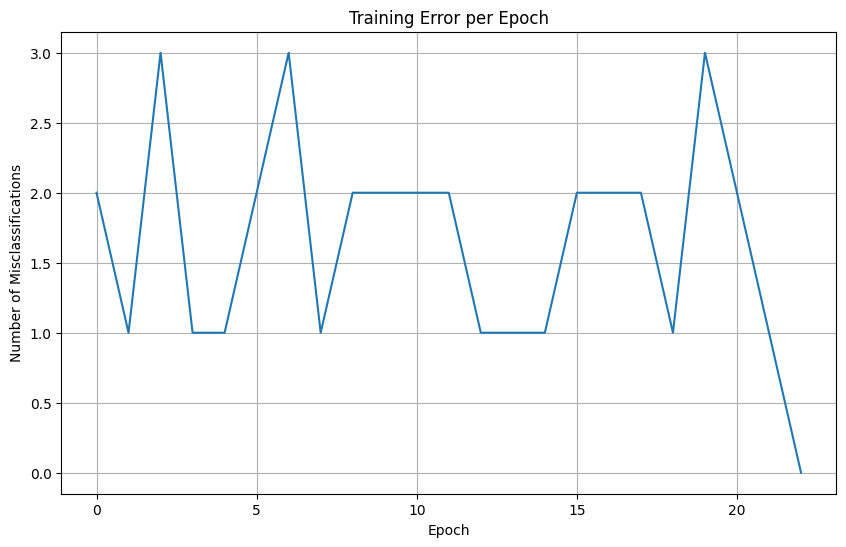

In [2]:
!pip install neuralink

import os
import neuralink
import cirq
import numpy as np
import random
import matplotlib.pyplot as plt

# ----------------------------------------------------
# A simplified Quantum Perceptron implementation
# ----------------------------------------------------

class QuantumPerceptron:
    def __init__(self, num_qubits):
        """Initializes a quantum perceptron.

        Args:
            num_qubits (int): The number of qubits, corresponding to the number of input features.
        """
        self.num_qubits = num_qubits
        self.qubits = [cirq.GridQubit(0, i) for i in range(num_qubits)]
        # Initialize quantum weights, which can be thought of as rotation angles
        self.weights = np.random.uniform(0, 2 * np.pi, num_qubits)

    def _create_circuit(self, inputs):
        """Creates the quantum circuit for a single forward pass.
        The circuit encodes input data and applies weighted rotations.

        Args:
            inputs (list or np.array): A list of classical input values (0 or 1).

        Returns:
            cirq.Circuit: The quantum circuit for this forward pass.
        """
        circuit = cirq.Circuit()

        # Apply inputs to qubits. This is where classical data becomes quantum state.
        for i, qubit in enumerate(self.qubits):
            if inputs[i] == 1:
                # Use a Hadamard gate to put the qubit in superposition
                circuit.append(cirq.H(qubit))

        # Apply the learned quantum weights as a rotation gate (Ry)
        for i, qubit in enumerate(self.qubits):
            circuit.append(cirq.ry(self.weights[i])(qubit))

        # A single measurement at the end to get the output
        circuit.append(cirq.measure(self.qubits[0], key='output'))

        return circuit

    def predict(self, inputs):
        """Makes a prediction based on the current weights and inputs.

        Args:
            inputs (list or np.array): The input data.

        Returns:
            int: The predicted output (0 or 1).
        """
        # Run the simulation
        simulator = cirq.Simulator()
        circuit = self._create_circuit(inputs)
        result = simulator.run(circuit, repetitions=1)

        # The result of the measurement is the prediction
        return result.measurements['output'][0][0]

    def train(self, training_data, learning_rate=0.1, epochs=100):
        """Trains the quantum perceptron using the perceptron learning rule.

        Args:
            training_data (list of tuples): A list of (input, label) pairs.
            learning_rate (float): The step size for weight updates.
            epochs (int): The number of training cycles.
        """
        history = []
        for epoch in range(epochs):
            error_count = 0
            for inputs, label in training_data:
                prediction = self.predict(inputs)
                error = label - prediction

                if error != 0:
                    error_count += 1
                    # Update weights based on the error.
                    # The update rule is simplified for this quantum model.
                    for i in range(self.num_qubits):
                        self.weights[i] += learning_rate * error * inputs[i]
                        # Clamp weights to stay within the rotation range [0, 2pi]
                        self.weights[i] = self.weights[i] % (2 * np.pi)

            history.append(error_count)
            if error_count == 0:
                print(f"Training converged after {epoch + 1} epochs.")
                break

        plt.figure(figsize=(10, 6))
        plt.plot(history)
        plt.title('Training Error per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Number of Misclassifications')
        plt.grid(True)
        plt.savefig('quantum_perceptron_training_error.png')
        print("Training finished. See 'quantum_perceptron_training_error.png' for the plot.")

# Main example usage
if __name__ == "__main__":
    # Define a simple dataset for an AND gate logic
    # (inputs, label)
    # The inputs are encoded as a classical list of 0s and 1s
    training_data = [
        ([0, 0], 0),
        ([0, 1], 0),
        ([1, 0], 0),
        ([1, 1], 1)
    ]

    # Initialize the perceptron with 2 qubits for 2 inputs
    qp = QuantumPerceptron(num_qubits=2)

    print("Initial predictions before training:")
    for inputs, _ in training_data:
        prediction = qp.predict(inputs)
        print(f"Inputs: {inputs}, Predicted: {prediction}")

    # Train the perceptron
    print("\nStarting training...")
    qp.train(training_data)

    print("\nFinal predictions after training:")
    for inputs, label in training_data:
        prediction = qp.predict(inputs)
        print(f"Inputs: {inputs}, Predicted: {prediction}, Expected: {label}")

In [ ]:
import neuralink
import os
import sys
import subprocess
import os
import cirq
import numpy as np
import matplotlib.pyplot as plt

# A function to ensure the necessary libraries are installed
def install_libraries():
    try:
        import cirq
        import numpy as np
        print("Required libraries are already installed.")
    except ImportError:
        print("Installing required libraries: cirq and numpy...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "cirq", "numpy"])
            print("Installation complete.")
        except subprocess.CalledProcessError as e:
            print(f"Failed to install libraries. Error: {e}")
            sys.exit(1)
        try:
            import cirq
            import numpy as np
        except ImportError:
            print("Failed to import libraries after installation. Please check your environment.")
            sys.exit(1)

install_libraries()

# ----------------------------------------------------
# Quantum Perceptron Class
# ----------------------------------------------------

class QuantumPerceptron:
    def __init__(self, num_qubits):
        self.num_qubits = num_qubits
        self.qubits = [cirq.GridQubit(0, i) for i in range(num_qubits)]
        self.weights = np.random.uniform(0, 2 * np.pi, num_qubits)

    def _create_circuit(self, inputs):
        circuit = cirq.Circuit()

        # Simple normalization to handle a wider range of inputs
        normalized_inputs = np.array(inputs) / np.max(np.abs(inputs))

        for i, qubit in enumerate(self.qubits):
            circuit.append(cirq.ry(normalized_inputs[i] * np.pi)(qubit))

        for i, qubit in enumerate(self.qubits):
            circuit.append(cirq.ry(self.weights[i])(qubit))

        circuit.append(cirq.measure(self.qubits[0], key='output'))

        return circuit

    def predict(self, inputs):
        simulator = cirq.Simulator()
        circuit = self._create_circuit(inputs)
        result = simulator.run(circuit, repetitions=1)
        return result.measurements['output'][0][0]

    def train(self, training_data, learning_rate=0.1, epochs=200):
        history = []
        for epoch in range(epochs):
            error_count = 0
            for inputs, label in training_data:
                prediction = self.predict(inputs)
                error = label - prediction

                if error != 0:
                    error_count += 1
                    for i in range(self.num_qubits):
                        self.weights[i] += learning_rate * error * inputs[i]
                        self.weights[i] = self.weights[i] % (2 * np.pi)

            history.append(error_count)
            if error_count == 0:
                print(f"Training converged after {epoch + 1} epochs.")
                break

        plt.figure(figsize=(10, 6))
        plt.plot(history)
        plt.title('Training Error per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Number of Misclassifications')
        plt.grid(True)
        plt.savefig('perceptron_training_error.png')
        print("Training finished. See 'perceptron_training_error.png' for the plot.")

# ----------------------------------------------------
# Main execution to parse and train
# ----------------------------------------------------
if __name__ == "__main__":
    raw_data = """8,0.465,0.979,0,64
9,0.675,0.955,0,64
10,0.516,0.983,0,64
11,0.507,0.963,0,64
12,0.477,0.989,0,64
13,0.508,0.898,0,64
14,0.498,0.984,0,64
15,0.474,0.921,0,64
16,0.510,0.978,0,64
17,0.517,0.976,0,64
18,0.608,0.970,0,64
19,0.418,0.940,0,64
20,0.506,0.976,0,64
21,0.508,0.932,0,64
22,0.535,0.974,0,64
23,0.512,0.967,0,64
24,0.489,0.938,0,64
25,0.490,0.917,0,64
26,0.391,0.969,0,64
27,0.522,0.974,0,64
28,0.492,0.913,0,64
29,0.482,0.986,0,64
30,0.541,0.972,0,64
31,0.486,0.987,0,64
32,0.490,0.983,0,64
33,0.489,0.981,0,64
34,0.498,0.983,0,64
35,0.506,0.944,0,64
36,0.528,0.986,0,64
37,0.494,0.955,0,64
38,0.495,0.972,0,64
39,0.483,0.954,0,64
40,0.458,0.986,0,64
41,0.505,0.985,0,64
42,0.513,0.988,0,64
43,0.509,0.916,0,64
44,0.518,0.981,0,64
45,0.520,0.926,0,64
46,0.509,0.928,0,64
47,0.501,0.972,0,64
48,0.492,0.984,0,64
49,0.483,0.986,0,64
50,0.492,0.988,0,64
51,0.508,0.951,0,64
52,0.503,0.980,0,64
53,0.538,0.987,0,64
54,0.495,0.941,0,64
55,0.476,0.987,0,64
56,0.493,0.985,0,64
57,0.464,0.980,0,64
58,0.509,0.982,0,64
59,0.508,0.987,0,64
60,0.489,0.985,0,64
61,0.513,0.982,0,64
62,0.404,0.985,0,64
63,0.494,0.951,0,64
64,0.509,0.986,0,64
65,0.535,0.920,0,64
66,0.501,0.948,0,64
67,0.517,0.985,0,64
68,0.493,0.965,0,64
69,0.416,0.988,0,64
70,0.489,0.987,0,64
71,0.494,0.970,0,64
72,0.507,0.985,0,64
73,0.501,0.914,0,64
74,0.467,0.983,0,64
75,0.508,0.981,0,64
76,0.502,0.982,0,64
77,0.464,0.980,0,64
78,0.488,0.977,0,64
79,0.519,0.954,0,64
80,0.499,0.984,0,64
81,0.477,0.988,0,64
82,0.425,0.973,0,64
83,0.504,0.925,0,64
84,0.601,0.921,0,64
85,0.512,0.964,0,64
86,0.517,0.982,0,64
87,0.465,0.987,0,64
88,0.501,0.943,0,64
89,0.504,0.983,0,64
90,0.475,0.905,0,64
91,0.553,0.991,0,64
92,0.491,0.945,0,64
93,0.448,0.947,0,64
94,0.522,0.959,0,64
95,0.485,0.907,0,64
96,0.552,0.986,0,64
97,0.408,0.984,0,64
98,0.480,0.984,0,64
99,0.462,0.988,0,64
100,0.536,0.986,0,64
101,0.501,0.957,0,64
102,0.524,0.900,0,64
103,0.507,0.958,0,64
104,0.507,0.968,0,64
105,0.455,0.987,0,64
106,0.514,0.968,0,64
107,0.499,0.975,0,64
108,0.507,0.988,0,64
109,0.512,0.913,0,64
110,0.520,0.970,0,64
111,0.537,0.988,0,64
112,0.504,0.984,0,64
113,0.450,0.927,0,64
114,0.512,0.986,0,64
115,0.494,0.980,0,64
116,0.505,0.985,0,64
117,0.517,0.966,0,64
118,0.497,0.951,0,64
119,0.496,0.965,0,64
120,0.495,0.986,0,64
121,0.282,0.986,0,64
122,0.506,0.930,0,64
123,0.486,0.982,0,64
124,0.504,0.931,0,64
125,0.480,0.922,0,64
126,0.494,0.980,0,64
127,0.525,0.985,0,64
128,0.508,0.964,0,64
129,0.508,0.943,0,64
130,0.486,0.988,0,64
131,0.443,0.986,0,64
132,0.494,0.982,0,64
133,0.523,0.985,0,64
134,0.533,0.955,0,64
135,0.494,0.920,0,64
136,0.505,0.962,0,64
137,0.493,0.973,0,64
138,0.509,0.983,0,64
139,0.520,0.981,0,64
140,0.505,0.981,0,64
141,0.511,0.985,0,64
142,0.512,0.985,0,64
143,0.504,0.969,0,64
144,0.479,0.987,0,64
145,0.487,0.985,0,64
146,0.524,0.989,0,64
147,0.494,0.981,0,64
148,0.520,0.925,0,64
149,0.510,0.965,0,64
150,0.403,0.979,0,64
151,0.499,0.986,0,64
152,0.486,0.953,0,64
153,0.504,0.972,0,64
154,0.523,0.985,0,64
155,0.553,0.987,0,64
156,0.500,0.984,0,64
157,0.489,0.985,0,64
158,0.531,0.987,0,64
159,0.518,0.980,0,64
160,0.491,0.984,0,64
161,0.503,0.977,0,64
162,0.499,0.978,0,64
163,0.499,0.970,0,64
164,0.496,0.966,0,64
165,0.488,0.984,0,64
166,0.489,0.947,0,64
167,0.458,0.980,0,64
168,0.501,0.987,0,64
169,0.491,0.976,0,64
170,0.475,0.926,0,64
171,0.511,0.984,0,64
172,0.482,0.932,0,64
173,0.505,0.989,0,64
174,0.480,0.985,0,64
175,0.504,0.974,0,64
176,0.527,0.976,0,64
177,0.498,0.910,0,64
178,0.487,0.989,0,64
179,0.478,0.977,0,64
180,0.501,0.972,0,64
181,0.491,0.984,0,64
182,0.499,0.948,0,64
183,0.478,0.984,0,64
184,0.503,0.986,0,64
185,0.483,0.964,0,64
186,0.496,0.978,0,64
187,0.510,0.937,0,64
188,0.496,0.975,0,64
189,0.404,0.986,0,64
190,0.484,0.981,0,64
191,0.471,0.911,0,64
192,0.520,0.968,0,64
193,0.508,0.978,0,64
194,0.491,0.981,0,64
195,0.492,0.970,0,64
196,0.487,0.984,0,64
197,0.491,0.979,0,64
198,0.506,0.971,0,64
199,0.488,0.982,0,64
200,0.531,0.987,0,64
201,0.517,0.986,0,64
202,0.545,0.961,0,64
203,0.498,0.986,0,64
204,0.489,0.982,0,64
205,0.466,0.986,0,64
206,0.503,0.981,0,64
207,0.509,0.988,0,64
208,0.497,0.987,0,64
209,0.494,0.977,0,64
210,0.508,0.984,0,64
211,0.491,0.967,0,64
212,0.494,0.948,0,64
213,0.499,0.982,0,64
214,0.485,0.973,0,64
215,0.568,0.977,0,64
216,0.503,0.920,0,64
217,0.514,0.952,0,64
218,0.499,0.939,0,64
219,0.538,0.986,0,64
220,0.481,0.986,0,64
221,0.502,0.974,0,64
222,0.501,0.986,0,64
223,0.492,0.985,0,64
224,0.540,0.956,0,64
225,0.454,0.991,0,64
226,0.595,0.983,0,64
227,0.452,0.987,0,64
228,0.507,0.985,0,64
229,0.468,0.985,0,64
230,0.559,0.962,0,64
231,0.420,0.972,0,64
232,0.491,0.989,0,64
233,0.506,0.965,0,64
234,0.492,0.922,0,64
235,0.353,0.989,0,64
236,0.494,0.985,0,64
237,0.489,0.986,0,64
238,0.509,0.986,0,64
239,0.523,0.927,0,64
240,0.508,0.987,0,64
241,0.494,0.989,0,64
242,0.504,0.973,0,64
243,0.499,0.970,0,64
244,0.540,0.968,0,64
245,0.481,0.981,0,64
246,0.395,0.917,0,64
247,0.512,0.981,0,64
248,0.504,0.948,0,64
249,0.488,0.991,0,64
250,0.490,0.987,0,64
251,0.452,0.985,0,64
252,0.504,0.977,0,64
253,0.496,0.969,0,64
254,0.495,0.973,0,64
255,0.502,0.961,0,64
"""

    # Process the raw data into a training dataset
    training_data = []
    lines = raw_data.strip().split('\n')
    for line in lines:
        parts = [float(p) for p in line.split(',')]
        # Using columns 1 and 2 (index 1 and 2) as features
        features = np.array([parts[1], parts[2]])
        # Creating a binary label: 1 if the third column is >= 0.97, else 0
        label = 1 if parts[2] >= 0.97 else 0
        training_data.append((features, label))

    # Initialize the perceptron with 2 qubits for the 2 features
    qp = QuantumPerceptron(num_qubits=2)

    print("Initial predictions before training:")
    for inputs, _ in training_data[:5]:
        prediction = qp.predict(inputs)
        print(f"Inputs: {inputs}, Predicted: {prediction}")

    print("\nStarting training...")
    qp.train(training_data)

    print("\nFinal predictions after training:")
    for inputs, label in training_data[-5:]:
        prediction = qp.predict(inputs)
        print(f"Inputs: {inputs}, Predicted: {prediction}, Expected: {label}")

Required libraries are already installed.
Initial predictions before training:
Inputs: [0.465 0.979], Predicted: 1
Inputs: [0.675 0.955], Predicted: 1
Inputs: [0.516 0.983], Predicted: 1
Inputs: [0.507 0.963], Predicted: 1
Inputs: [0.477 0.989], Predicted: 1

Starting training...
